In [ ]:
!pip install git+https://github.com/Starlitnightly/dynamo-release.git

In [1]:
import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
print(f'dynamo version: {dyn.__version__}')

/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/an

dynamo version: 1.4.2rc1


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


In [2]:
#adata=dyn.read('data/setty_bone_marrow.h5ad')
adata=dyn.sample_data.bone_marrow()
adata

|-----> Downloading data to ./data/bone_marrow.h5ad
|-----> File ./data/bone_marrow.h5ad already exists.


AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

In [3]:
adata.layers['counts']=adata.X.copy()

In [4]:
adata=adata[~adata.obs['clusters'].isin(['CLP'])]
adata

View of AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced', 'counts'

In [ ]:
preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True)
preprocessor.preprocess_adata(adata, recipe='monocle')

In [ ]:
dyn.tl.reduceDimension(adata)
adata

In [ ]:
del adata.uns['neighbors']
dyn.tl.reduceDimension(adata)

In [ ]:
#dyn.tl.reduceDimension(adata)
dyn.pl.umap(adata, color='clusters',
           save_show_or_return='show',
            adjust_legend=True)

In [ ]:
adata

In [ ]:
adata.layers['M_s']=adata.X
dyn.tl.pseudotime_velocity(adata,
                          pseudotime='palantir_pseudotime')

In [ ]:
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

In [10]:
color_dict={'HSC_1': '#fcd4e4',
 'HSC_2': '#f494a4',
 'Ery_1': '#cc141c',
 'Mono_1': '#043464',
 'Precursors': '#acd4ec',
 'Mono_2': '#3474ac',
 'DCs': '#143c3c',
 'Ery_2': '#8c1c24',
 'Mega': '#fcc43c'}

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


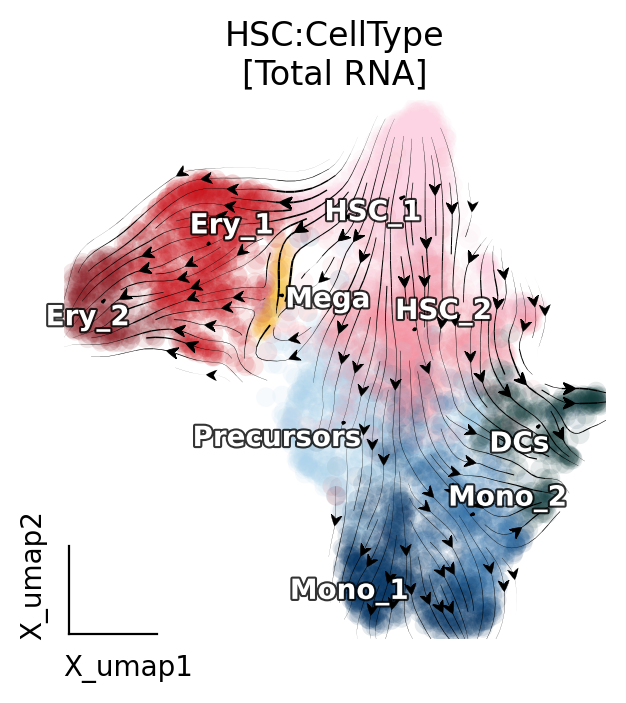

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       color_key=color_dict,
                       title='HSC:CellType',
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title('HSC:CellType\n[Total RNA]',fontsize=12)

coords=adata.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)


fig.savefig(f'figures/fig3/Pt_HSC_Velo.png', dpi=300, bbox_inches='tight')

In [ ]:
# you can set `verbose = 1/2/3` to obtain different levels of running information of vector field reconstruction

dyn.vf.VectorField(adata, basis='umap', M=100,
                   cores=12,map_topography=True,
                   pot_curl_div=True) 

In [8]:
dyn.vf.VectorField(adata, basis='umap', 
                   cores=12,) 

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [3.6775s]
|-----> [VectorField] completed [3.8585s]


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin' will be ignored
  ax.scatter(
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker (<matplotlib.markers.MarkerStyle object at 0x7fa03a0f8b50>).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker (<matplotlib.markers.MarkerStyle object at 0x7fa03a0fa800>).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


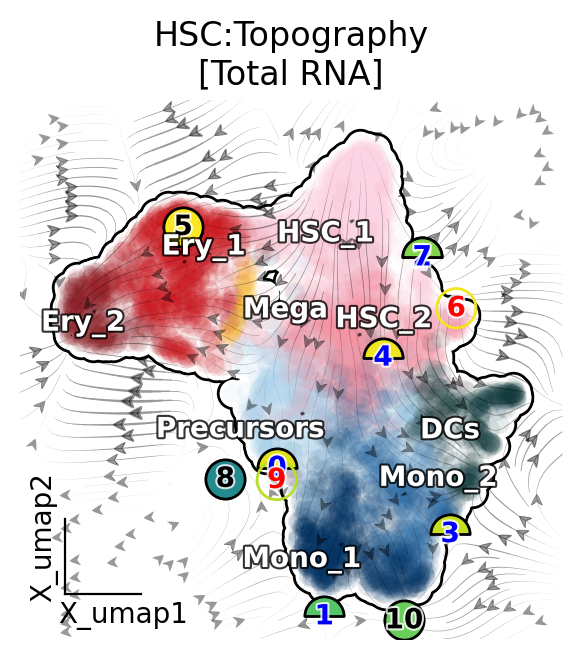

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.topography(adata, basis='umap', background='white', 
                  color=[ 'clusters'], 
                  color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('HSC:Topography\n[Total RNA]',fontsize=12)

coords=adata.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, 0.07)
ax.yaxis.set_label_coords(0.07, 0.07)
fig.savefig(f'figures/fig3/Pt_HSC_Topography.png', dpi=300, bbox_inches='tight')

|-----------> plotting with basis key=X_umap


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin' will be ignored
  ax.scatter(
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker (<matplotlib.markers.MarkerStyle object at 0x7fa039d25e70>).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/dynamo/plot/topography.py:552: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker (<matplotlib.markers.MarkerStyle object at 0x7fa016824550>).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


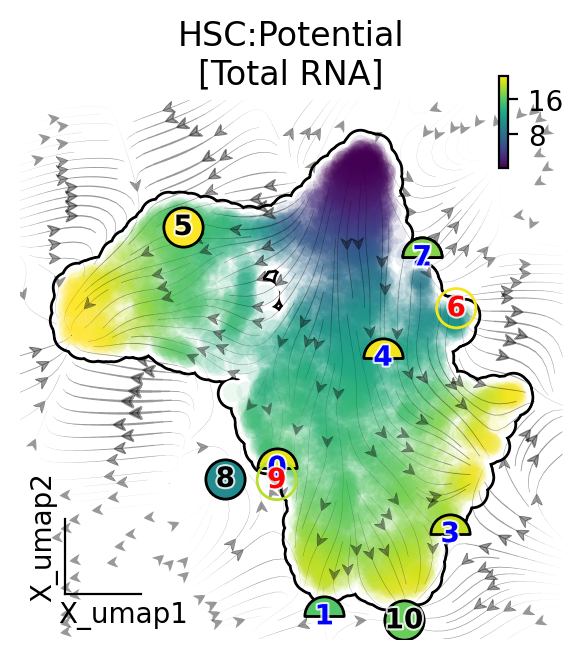

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.topography(adata, basis='umap', background='white', 
                  color=[ 'umap_ddhodge_potential'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
ax.set_title('HSC:Potential\n[Total RNA]',fontsize=12)

coords=adata.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, 0.07)
ax.yaxis.set_label_coords(0.07, 0.07)

fig.savefig(f'figures/fig3/Pt_HSC_Potential.png', dpi=300, bbox_inches='tight')
#fig

In [14]:
adata.write('data/rna_pp/hsc_pseu_visual.h5ad')

In [7]:
adata=dyn.read('data/rna_pp/hsc_pseu_visual.h5ad')

/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
